# `waveoptics` tutorial

This notebook teaches the thin-film optics tools in `empylib.waveoptics`, from a single interface to coherent and incoherent multilayer stacks.

**Learning goals**

- compute Fresnel coefficients at a single interface
- distinguish coherent and incoherent multilayer modeling
- use `snell` to verify transmitted angles in layered systems

**Notebook design**

- every runnable cell calls the public `empylib` API directly
- parameter meanings are explained in markdown and in short inline comments
- outputs are inspected in the same notebook so you can see what each function returns
- the core path is offline-first; internet-backed examples live in clearly marked optional appendices

In [1]:
from pathlib import Path
import os
import sys

current = Path.cwd().resolve()
for candidate in (current, *current.parents):
    if (candidate / "empylib").exists() and (candidate / "docs").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the EMPI Lib repository root.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (7, 3)

import empylib.waveoptics as wv

## Single interface and transmitted angle

**Functions used**

- wv.interface
- wv.snell

**Problem we are solving**

Start with the simplest optical boundary: one medium above, one medium below. The library gives you reflectance, transmittance, and the complex field coefficients, while `snell` lets you verify the transmitted angle explicitly.

**Parameter guide for this example**

- `N_above`: refractive index of the incident medium
- `N_below`: refractive index of the transmitted medium; it can be scalar or wavelength-dependent
- `aoi`: angle of incidence in radians; here we pass three angles at once
- `polarization='TM'`: choose between TE and TM polarization

**Outputs to inspect**

- `R` and `T`: interface reflectance and transmittance
- `r` and `t`: complex field reflection and transmission coefficients
- `theta_t`: transmitted angle from Snell's law

R shape: (3, 160)
T shape: (3, 160)
Transmitted angle at 35 deg incidence: 22.4814495355 deg


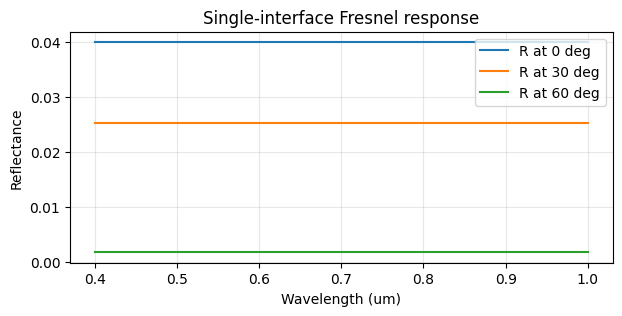

In [2]:
lam = np.linspace(0.40, 1.00, 160)
aoi = np.radians([0.0, 30.0, 60.0])
n_below = 1.50 + 0.01j + 0 * lam

R, T, r, t = wv.interface(
    1.00,          # N_above: refractive index of the incident medium
    n_below,       # N_below: wavelength-dependent refractive index below the interface
    aoi=aoi,       # incidence angle(s) in radians
    polarization="TM",
)

theta_t = wv.snell(
    1.00,
    1.50,
    np.radians(35.0),  # incident angle in radians
)

print("R shape:", np.asarray(R).shape)
print("T shape:", np.asarray(T).shape)
print("Transmitted angle at 35 deg incidence:", np.degrees(theta_t), "deg")

fig, ax = plt.subplots()
ax.plot(lam, R[0], label="R at 0 deg")
ax.plot(lam, R[1], label="R at 30 deg")
ax.plot(lam, R[2], label="R at 60 deg")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Reflectance")
ax.set_title("Single-interface Fresnel response")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

At larger incidence angles the TM response changes strongly, which is why angle and polarization control matter so much in thin-film design. The output shapes also show that the function can evaluate several angles in one call.

**Common pitfalls**

- Angles are in radians, not degrees
- If one refractive index is wavelength-dependent and the other is scalar, the library broadcasts the scalar automatically
- For absorbing media, `r` and `t` are complex amplitudes; inspect `R` and `T` for energy flow

**Try this next**

- Switch `polarization` to `'TE'` and compare the angle dependence
- Use a complex `N_above` to model an absorbing incident medium

## Coherent multilayer stack

**Functions used**

- wv.multilayer

**Problem we are solving**

When your layers are optically coherent, interference between multiple reflections shapes the spectrum. This example builds a two-layer stack and computes its coherent reflectance and transmittance.

**Parameter guide for this example**

- `N_layers`: list of layer refractive indices from top to bottom
- `thickness`: thickness of each layer in micrometers
- `N_above` and `N_below`: refractive index of the incident and substrate media
- `aoi`: angle of incidence in radians

**Outputs to inspect**

- `R` and `T`: coherent reflectance and transmittance spectra
- `r` and `t`: complex stack amplitudes

First coherent R/T pair: 0.206206456556 0.768258005114


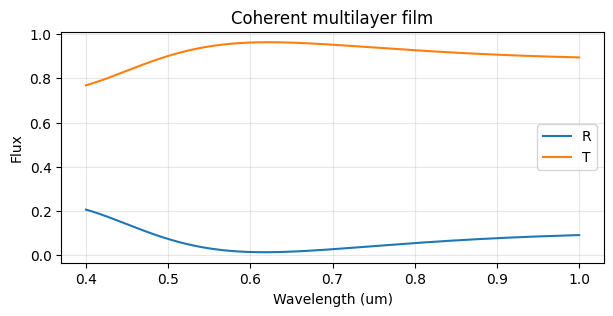

In [3]:
lam_stack = np.linspace(0.40, 1.00, 180)
n_layers = [
    1.45 + 0.00j + 0 * lam_stack,
    2.10 + 0.02j + 0 * lam_stack,
]
thickness = [0.12, 0.05]

R_coh, T_coh, r_coh, t_coh = wv.multilayer(
    lam_stack,
    aoi=np.radians(15.0),   # incidence angle in radians
    N_layers=n_layers,      # list of layer refractive indices
    thickness=thickness,    # layer thicknesses in micrometers
    N_above=1.00,           # incident medium
    N_below=1.52,           # substrate
)

print("First coherent R/T pair:", R_coh[0], T_coh[0])

fig, ax = plt.subplots()
ax.plot(lam_stack, R_coh, label="R")
ax.plot(lam_stack, T_coh, label="T")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Flux")
ax.set_title("Coherent multilayer film")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The oscillatory structure is the interference signature of a coherent stack. Layer thickness and optical thickness control where the extrema appear.

**Common pitfalls**

- The `N_layers` and `thickness` lists must have the same number of entries
- If you accidentally pass thickness in nanometers, the interference pattern will be completely wrong

**Try this next**

- Double one layer thickness and watch the fringes shift
- Replace one layer index with a real material from `nklib`

## Partially incoherent multilayer stack

**Functions used**

- wv.incoh_multilayer

**Problem we are solving**

Real coatings can become incoherent when the coherence length is shorter than the optical path differences in the stack. `incoh_multilayer` approximates that regime.

**Parameter guide for this example**

- `coh_length`: coherence length in micrometers used to decide whether interference survives
- the remaining arguments mirror the coherent stack API so you can compare the two models directly

**Outputs to inspect**

- `R_incoh` and `T_incoh`: incoherent reflectance and transmittance spectra
- a side-by-side comparison against the coherent result

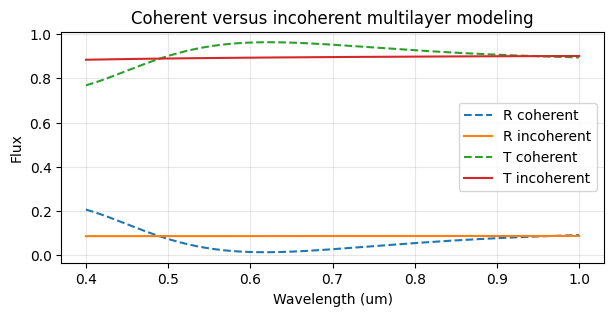

In [4]:
R_incoh, T_incoh = wv.incoh_multilayer(wavelength = lam_stack,
                                        N_layers=n_layers,
                                        thickness=thickness,
                                        aoi=np.radians(15.0),
                                        N_above=1.00,
                                        N_below=1.52,
                                        coh_length=0.03,  # coherence length in micrometers
)

fig, ax = plt.subplots()
ax.plot(lam_stack, R_coh, "--", label="R coherent")
ax.plot(lam_stack, R_incoh, label="R incoherent")
ax.plot(lam_stack, T_coh, "--", label="T coherent")
ax.plot(lam_stack, T_incoh, label="T incoherent")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Flux")
ax.set_title("Coherent versus incoherent multilayer modeling")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The incoherent spectrum is smoother because some interference detail has been averaged out. This is often closer to what you measure in rough, thick, or broadband-illuminated stacks.

**Common pitfalls**

- A very short `coh_length` can wash out structure you may still want to resolve
- A coherence model is still an approximation; if surface roughness or scattering is strong, a wave-only model may not be enough

**Try this next**

- Increase `coh_length` to see the result move back toward the coherent case
- Compare the same stack at a larger angle of incidence